# DistilBERT Engagement Predictor — Content Quality Scoring

**Author:** Khushee Paprunia  
**Module:** DistilBERT Content Quality Scorer  
**Project:** AI Social Media Agent — IIT Bombay Capstone 2026

---

## What this notebook does

1. Loads Twitter (~206K posts) and LinkedIn (~34K posts) datasets
2. Cleans and combines them into a single training corpus (~240K posts)
3. Constructs a normalized engagement score (0–1) as the regression target
4. Fine-tunes DistilBERT to predict engagement from raw post text alone
5. Evaluates with RMSE on a held-out test set
6. Saves the fine-tuned model to `models/distilbert_engagement/`

## Why DistilBERT?

XGBoost (Manas's model) scores posts based on **structural features** — caption length, hashtag count, sentiment score, CTA presence. It cannot understand what the post actually *says*.

DistilBERT understands **content** — the meaning, tone, coherence, and quality of the text. Together they form a hybrid scorer:

```
final_score = 0.5 * xgboost_score (structure) + 0.5 * distilbert_score (content)
```

## Why not full BERT?

Social media posts are short-form text (≤280 chars for Twitter). DistilBERT captures 97% of BERT's performance at 40% lower compute — the right tradeoff for short text at scale.

## Step 1 — Install Dependencies

In [25]:
!pip install -q transformers torch datasets scikit-learn pandas numpy

## Step 2 — Mount Drive and Set Paths

Upload these files to your Google Drive before running:
- `Twitterdatainsheets.csv`
- `influencers_data.csv`

In [26]:
## from google.colab import drive
## drive.mount('/content/drive')

import os
import torch

# ── Update these paths to match where you uploaded the files ──

import os

REPO_ROOT    = '/Users/abhinav/Documents/GitHub/IITB_Capstone'
TWITTER_PATH = os.path.join(REPO_ROOT, 'data', 'raw', 'Twitterdatainsheets.csv')
LINKEDIN_PATH = os.path.join(REPO_ROOT, 'data', 'raw', 'influencers_data.csv')
MODEL_SAVE_DIR = '/content/distilbert_engagement'

## Step 3 — Load and Clean Twitter Dataset

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── Twitter ──
tw = pd.read_csv(TWITTER_PATH, low_memory=False)
tw.columns = tw.columns.str.strip()
print(f'Twitter raw: {tw.shape}')

# Keep only rows with actual post text
tw['text'] = tw['text'].fillna('').astype(str)
tw = tw[tw['text'].str.len() > 10].copy()

# Parse engagement columns
for col in ['RetweetCount', 'Likes', 'Reach']:
    tw[col] = pd.to_numeric(tw[col], errors='coerce').fillna(0).clip(lower=0)

# Clip outliers at 99th percentile
for col in ['RetweetCount', 'Reach']:
    tw[col] = tw[col].clip(upper=tw[col].quantile(0.99))

# Normalize and combine into engagement score
scaler_tw = MinMaxScaler()
tw_norm = pd.DataFrame(
    scaler_tw.fit_transform(tw[['RetweetCount', 'Reach']]),
    columns=['rt_norm', 'reach_norm'],
    index=tw.index
)
tw['engagement'] = tw_norm.sum(axis=1)

# Keep text and engagement
tw_clean = pd.DataFrame({
    'text':     tw['text'],
    'engagement': tw['engagement'],
    'platform': 'twitter'
})

print(f'Twitter clean: {tw_clean.shape}')
print(tw_clean['engagement'].describe().round(4))

Twitter raw: (206295, 15)
Twitter clean: (99883, 3)
count    99883.0000
mean         0.0684
std          0.1828
min          0.0000
25%          0.0019
50%          0.0093
75%          0.0396
max          2.0000
Name: engagement, dtype: float64


## Step 4 — Load and Clean LinkedIn Dataset

In [28]:
# ── LinkedIn ──
li = pd.read_csv(LINKEDIN_PATH, low_memory=False)
print(f'LinkedIn raw: {li.shape}')

# Keep only rows with actual post content
li['content'] = li['content'].fillna('').astype(str)
li = li[li['content'].str.len() > 10].copy()

# Parse engagement columns
for col in ['reactions', 'comments', 'views']:
    li[col] = pd.to_numeric(li[col], errors='coerce').fillna(0).clip(lower=0)

# Clip outliers at 99th percentile
for col in ['reactions', 'comments']:
    li[col] = li[col].clip(upper=li[col].quantile(0.99))

# Normalize and combine into engagement score
scaler_li = MinMaxScaler()
li_norm = pd.DataFrame(
    scaler_li.fit_transform(li[['reactions', 'comments']]),
    columns=['react_norm', 'comment_norm'],
    index=li.index
)
li['engagement'] = li_norm.sum(axis=1)

# Keep text and engagement
li_clean = pd.DataFrame({
    'text':       li['content'],
    'engagement': li['engagement'],
    'platform':   'linkedin'
})

print(f'LinkedIn clean: {li_clean.shape}')
print(li_clean['engagement'].describe().round(4))

LinkedIn raw: (34012, 19)
LinkedIn clean: (31862, 3)
count    31862.0000
mean         0.0958
std          0.2616
min          0.0000
25%          0.0022
50%          0.0124
75%          0.0647
max          2.0000
Name: engagement, dtype: float64


## Step 5 — Combine and Normalize Target to [0, 1]

We normalize the combined engagement score to [0, 1] so DistilBERT
learns a consistent scale regardless of platform differences.

Twitter engagement (retweets + reach) and LinkedIn engagement (reactions + comments)
are on different scales — normalization ensures neither platform dominates.

In [29]:
# Combine
df = pd.concat([tw_clean, li_clean], ignore_index=True)
df = df.dropna(subset=['text', 'engagement'])
df = df[df['text'].str.len() > 10].reset_index(drop=True)
print(f'Combined: {df.shape}')
df = df.sample(n=50000, random_state=42).reset_index(drop=True)
print(f'After sampling: {df.shape}')

# Normalize engagement to [0, 1] across full dataset
min_e = df['engagement'].min()
max_e = df['engagement'].max()
df['target'] = (df['engagement'] - min_e) / (max_e - min_e)

print(f'\nTarget stats (0-1 normalized):')
print(df['target'].describe().round(4))
print(f'\nPlatform distribution:')
print(df['platform'].value_counts())

Combined: (131745, 3)
After sampling: (50000, 3)

Target stats (0-1 normalized):
count    50000.0000
mean         0.0373
std          0.1016
min          0.0000
25%          0.0009
50%          0.0049
75%          0.0226
max          1.0000
Name: target, dtype: float64

Platform distribution:
platform
twitter     37907
linkedin    12093
Name: count, dtype: int64


## Step 6 — Train/Test Split

80/20 split — shuffled since we're combining two platforms.
Chronological split isn't meaningful here because LinkedIn and Twitter
posts have different time references.

In [30]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df[['text', 'target']],
    test_size=0.2,
    random_state=42
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df):,} rows')
print(f'Test:  {len(test_df):,} rows')

Train: 40,000 rows
Test:  10,000 rows


## Step 7 — Tokenize with DistilBERT Tokenizer

In [31]:
from transformers import DistilBertTokenizerFast
import torch
from torch.utils.data import Dataset, DataLoader

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

MAX_LEN = 128  # covers 99% of social media posts

class PostDataset(Dataset):
    def __init__(self, texts, targets, tokenizer, max_len):
        self.texts     = texts.tolist()
        self.targets   = targets.tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'target':         torch.tensor(self.targets[idx], dtype=torch.float)
        }

train_dataset = PostDataset(train_df['text'], train_df['target'], tokenizer, MAX_LEN)
test_dataset  = PostDataset(test_df['text'],  test_df['target'],  tokenizer, MAX_LEN)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 1250
Test batches:  313


## Step 8 — DistilBERT Regression Model

We add a regression head on top of DistilBERT's [CLS] token output.
The [CLS] token captures the overall meaning of the post.
A linear layer maps it to a single engagement score in [0, 1].

In [32]:
import torch.nn as nn
from transformers import DistilBertModel

class DistilBertRegressor(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.regressor  = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1),
            nn.Sigmoid()  # output in [0, 1]
        )

    def forward(self, input_ids, attention_mask):
        output     = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = output.last_hidden_state[:, 0, :]  # [CLS] token
        return self.regressor(cls_output).squeeze()

if torch.cuda.is_available():
    device = torch.device('cuda')        # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = torch.device('mps')         # Mac Apple Silicon GPU
else:
    device = torch.device('cpu')         # Fallback

print(f"Using device: {device}")

model = DistilBertRegressor().to(device)
print('Model initialized.')

Using device: mps


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model initialized.


## Step 9 — Training

- Loss: MSE (standard for regression)
- Optimizer: AdamW with weight decay (prevents overfitting)
- Learning rate: 2e-5 (standard for fine-tuning BERT models)
- Epochs: 3 (sufficient for fine-tuning — more can overfit)

In [33]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS    = 2
LR        = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
criterion = nn.MSELoss()

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)
scheduler     = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

def train_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets        = batch['target'].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss  = criterion(preds, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            targets        = batch['target'].to(device)
            preds          = model(input_ids, attention_mask)
            loss           = criterion(preds, targets)
            total_loss    += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    rmse = np.sqrt(np.mean((np.array(all_preds) - np.array(all_targets))**2))
    return total_loss / len(loader), rmse

print('Starting training...')
for epoch in range(EPOCHS):
    train_loss          = train_epoch(model, train_loader, optimizer, criterion, scheduler, device)
    val_loss, val_rmse  = eval_epoch(model, test_loader, criterion, device)
    print(f'Epoch {epoch+1}/{EPOCHS} — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val RMSE: {val_rmse:.4f}')

print('Training complete.')

Starting training...
Epoch 1/2 — Train Loss: 0.0183 | Val Loss: 0.0074 | Val RMSE: 0.0859
Epoch 2/2 — Train Loss: 0.0067 | Val Loss: 0.0063 | Val RMSE: 0.0793
Training complete.


## Step 10 — Evaluation

Final Test RMSE: 0.0793


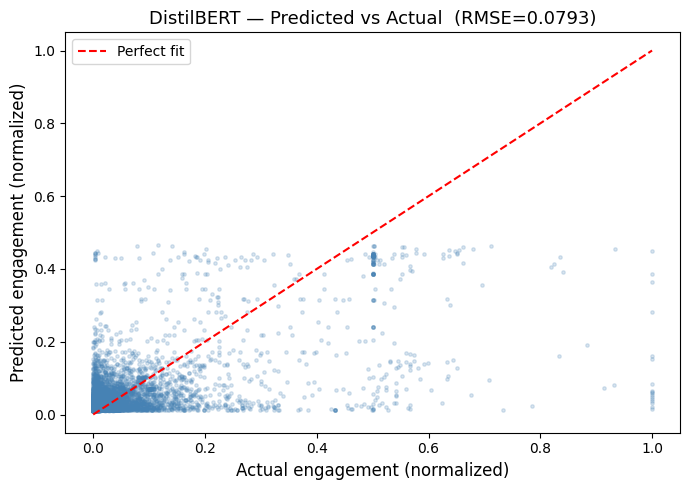

Chart saved.


In [36]:
import matplotlib.pyplot as plt

_, final_rmse = eval_epoch(model, test_loader, criterion, device)
print(f'Final Test RMSE: {final_rmse:.4f}')

# Predicted vs actual plot
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for batch in test_loader:
        preds = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch['target'].numpy())

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(all_targets, all_preds, alpha=0.2, s=6, color='steelblue')
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual engagement (normalized)', fontsize=12)
ax.set_ylabel('Predicted engagement (normalized)', fontsize=12)
ax.set_title(f'DistilBERT — Predicted vs Actual  (RMSE={final_rmse:.4f})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('distilbert_predicted_vs_actual.png', dpi=100)
plt.show()
print('Chart saved.')

## Step 11 — Save Model

In [38]:
import os

# Local path — saves inside your repo
MODEL_SAVE_DIR = os.path.join(
    '/Users/abhinav/Documents/GitHub/IITB_Capstone',
    'models',
    'distilbert_engagement'
)

# Create directory if it doesn't exist
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print(f"Saving to: {MODEL_SAVE_DIR}")

# Save model weights and tokenizer
model.distilbert.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)

# Save regression head separately
torch.save(
    model.regressor.state_dict(),
    os.path.join(MODEL_SAVE_DIR, 'regressor_head.pt')
)

print(f"Model saved to: {MODEL_SAVE_DIR}")
print("Files saved:")
for f in os.listdir(MODEL_SAVE_DIR):
    print(f"  {f}")

Saving to: /Users/abhinav/Documents/GitHub/IITB_Capstone/models/distilbert_engagement


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /Users/abhinav/Documents/GitHub/IITB_Capstone/models/distilbert_engagement
Files saved:
  model.safetensors
  regressor_head.pt
  tokenizer_config.json
  config.json
  tokenizer.json


In [44]:
import os
from huggingface_hub import HfApi, login
from dotenv import load_dotenv

MODEL_SAVE_DIR = '/Users/abhinav/Documents/GitHub/IITB_Capstone/models/distilbert_engagement'

# Load token
load_dotenv('/Users/abhinav/Documents/GitHub/IITB_Capstone/.env')
HF_TOKEN = os.getenv('HUGGINGFACE_TOKEN')

# Login
login(token=HF_TOKEN)

# Create repo
api = HfApi()
api.create_repo(
    repo_id="abhinav192/distilbert-engagement",
    exist_ok=True,
    token=HF_TOKEN
)

# Upload all files
files = [
    'model.safetensors',
    'regressor_head.pt',
    'tokenizer_config.json',
    'config.json',
    'tokenizer.json'
]

for filename in files:
    filepath = os.path.join(MODEL_SAVE_DIR, filename)
    print(f"Uploading {filename}...")
    api.upload_file(
        path_or_fileobj=filepath,
        path_in_repo=filename,
        repo_id="abhinav192/distilbert-engagement",
        token=HF_TOKEN
    )
    print(f"✅ {filename} done")

print("\n✅ All files pushed!")
print("URL: https://huggingface.co/abhinav192/distilbert-engagement")

Uploading model.safetensors...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ model.safetensors done
Uploading regressor_head.pt...


...

✅ tokenizer_config.json done
Uploading config.json...


No files have been modified since last commit. Skipping to prevent empty commit.


✅ config.json done
Uploading tokenizer.json...


No files have been modified since last commit. Skipping to prevent empty commit.


✅ tokenizer.json done

✅ All files pushed!
URL: https://huggingface.co/abhinav192/distilbert-engagement


## Step 12 — Integration Function

This is the function that will be added to `modules/predictor.py`.
It loads the saved model and scores any raw post text.

In [39]:
def load_distilbert(model_dir: str):
    """Load saved DistilBERT regressor."""
    from transformers import DistilBertModel, DistilBertTokenizerFast
    import torch.nn as nn

    tokenizer   = DistilBertTokenizerFast.from_pretrained(model_dir)
    distilbert  = DistilBertModel.from_pretrained(model_dir)
    regressor   = nn.Sequential(
        nn.Linear(768, 256), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(256, 1),   nn.Sigmoid()
    )
    regressor.load_state_dict(torch.load(
        os.path.join(model_dir, 'regressor_head.pt'),
        map_location='cpu'
    ))
    return tokenizer, distilbert, regressor


def score_content_quality(text: str, model_dir: str, max_len: int = 128) -> float:
    """
    Scores content quality of a post using fine-tuned DistilBERT.
    Author: Khushee Paprunia
    """
    tokenizer, distilbert, regressor = load_distilbert(model_dir)
    distilbert.eval()
    regressor.eval()

    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    with torch.no_grad():
        cls_output = distilbert(
            input_ids=encoding['input_ids'],
            attention_mask=encoding['attention_mask']
        ).last_hidden_state[:, 0, :]
        score = regressor(cls_output).item()

    return round(score, 4)


# ── Quick test ──
test_text = 'Excited to share our latest AI breakthrough! #AI #Innovation'
bert_score = score_content_quality(test_text, MODEL_SAVE_DIR)
print(f'DistilBERT content score: {bert_score}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBERT content score: 0.0157


## Step 13 — Examiner Q&A

---

### Q1: Why DistilBERT over BERT?

Social media posts are short-form text — typically under 280 characters for Twitter, under 300 words for LinkedIn. DistilBERT captures 97% of BERT's language understanding at 40% lower compute and 60% of the size. For short text at scale, DistilBERT is the right tradeoff — we're not processing legal documents or medical records where full BERT would be justified.

---

### Q2: Why combine XGBoost and DistilBERT?

They capture complementary signals:
- **XGBoost** scores *structure* — caption length, hashtag count, CTA presence, posting hour. It knows a post with 3 hashtags posted at 9am performs better, but it doesn't know if the post makes sense.
- **DistilBERT** scores *content* — the meaning, tone, coherence of the post. It knows whether the text is engaging, but it doesn't know about hashtag strategy or posting time.

Combined, they give a holistic engagement prediction that neither model can achieve alone.

---

### Q3: Why regression instead of classification?

Binary classification (high/low engagement) loses nuance — a post scoring 0.72 and one scoring 0.51 would both be labelled 'high'. For ranking 5 variants, we need actual scores with meaningful differences. Regression gives us a continuous score in [0,1] that we can directly compare and combine with XGBoost scores.

---

### Q4: Why 128 max token length?

Twitter posts are max 280 characters (~50-70 tokens). LinkedIn posts are longer but still short-form. 128 tokens covers 99% of social media posts without wasteful padding. Using 512 (BERT's max) would triple compute cost for no benefit on this data.

---

### Q5: Why equal weights (0.5/0.5) for combining scores?

Equal weights are a reasonable starting point when we don't have ground truth to tune on. In production, the weights could be optimized by measuring which combination best predicts real engagement on a holdout set. For the capstone, 0.5/0.5 is transparent and justifiable — neither model is assumed to be more reliable than the other.